In [1]:
import pandas as pd
import matplotlib.pyplot as plt

market = pd.read_csv("../data/market_master.csv")

market["Date"] = pd.to_datetime(market["Date"])
market = market.set_index("Date")

In [2]:
market["mom_5"] = market["nifty_close"].pct_change(5)
market["mom_20"] = market["nifty_close"].pct_change(20)

market["ma_20"] = market["nifty_close"].rolling(20).mean()
market["ma_50"] = market["nifty_close"].rolling(50).mean()

market["trend_signal"] = (market["ma_20"] - market["ma_50"]) / market["nifty_close"]

market["mom_diff"] = market["mom_5"] - market["mom_20"]

In [3]:
market.describe()

,nifty_close,nifty_ret,bank_close,bank_ret,relative_strength,breadth_signal,vix,usd_inr,crude,vix_ret,...,position_change,cost,strategy_ret,equity_curve,mom_5,mom_20,ma_20,ma_50,trend_signal,mom_diff
count,1739.000000,1739.000000,1739.000000,1739.000000,1739.000000,1739.000000,1739.000000,1739.000000,1739.000000,1739.000000,...,1739.000000,1739.000000,1739.000000,1739.000000,1734.000000,1719.000000,1720.000000,1690.000000,1690.000000,1719.000000
mean,17951.773019,0.000501,40224.619777,0.000509,0.000008,0.000008,17.266252,79.238725,68.553019,0.001637,...,0.129960,0.000065,0.000220,1.425551,0.002475,0.010246,17956.470129,17948.306048,0.005771,-0.007900
std,5055.161123,0.011127,10748.512583,0.014889,0.007029,0.002343,7.304246,6.039491,17.818545,0.056407,...,0.336356,0.000168,0.006657,0.198124,0.024220,0.049643,5029.329490,4975.056363,0.030602,0.042956
min,7610.250000,-0.129805,16917.453125,-0.167340,-0.046673,-0.013524,9.150000,68.367599,-37.630001,-0.297503,...,0.000000,0.000000,-0.059294,1.021896,-0.190239,-0.370057,8572.712451,8983.414961,-0.214374,-0.215028
25%,13429.625000,-0.004462,31721.906250,-0.005897,-0.003535,-0.001268,13.045000,73.987549,58.630001,-0.027236,...,0.000000,0.000000,-0.000500,1.241763,-0.009595,-0.013735,13583.494971,13817.370498,-0.008234,-0.031842
50%,17691.250000,0.000792,39455.441406,0.000905,-0.000190,0.000047,15.420000,79.882896,69.339996,-0.003526,...,0.000000,0.000000,0.000000,1.467802,0.003348,0.011294,17664.225000,17564.642051,0.008798,-0.008470
75%,22657.250000,0.006155,48738.974609,0.007056,0.003441,0.001321,19.799999,83.508049,78.739998,0.023318,...,0.000000,0.000000,0.000879,1.580809,0.015683,0.037989,22698.819604,22953.008564,0.022795,0.013956
max,26328.550781,0.087632,61550.800781,0.105117,0.041167,0.009593,83.610001,93.246597,123.699997,0.656250,...,1.000000,0.000500,0.047424,1.764365,0.105221,0.202904,26044.980176,25971.740117,0.055123,0.348882


In [4]:
market[["mom_5","mom_20","trend_signal","mom_diff"]].tail()

,mom_5,mom_20,trend_signal,mom_diff
Date,,,,
2026-03-16,-0.025772,-0.080966,-0.021635,0.055194
2026-03-17,-0.028046,-0.081829,-0.023757,0.053783
2026-03-18,-0.003731,-0.075707,-0.025511,0.071976
2026-03-19,-0.026947,-0.109112,-0.029670,0.082165
2026-03-20,-0.001581,-0.091923,-0.031936,0.090342


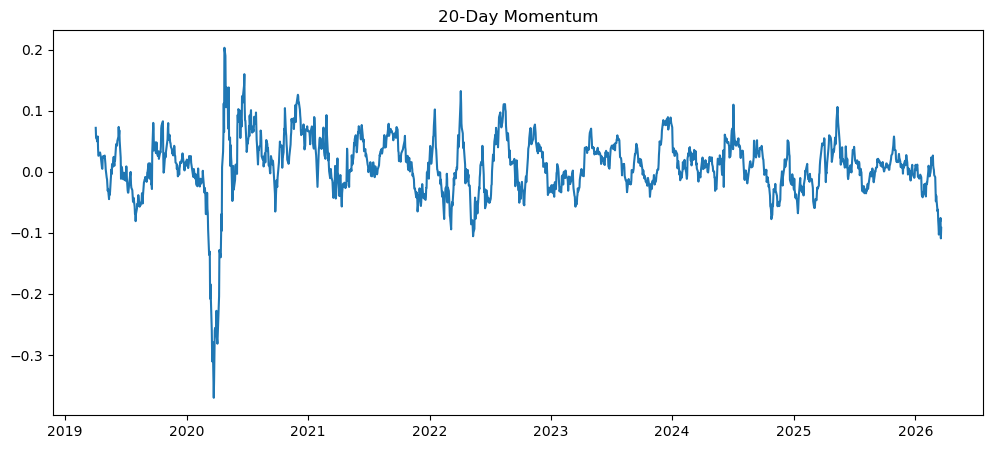

In [5]:
plt.figure(figsize=(12,5))
plt.plot(market.index, market["mom_20"])
plt.title("20-Day Momentum")
plt.show()

In [6]:
market = market.dropna()

market.to_csv("../data/market_master.csv")